# Pokémon Statistical Study: Dispersion in Attack Stats

### Research Question
> **How dispersed are the Attack statistics across different primary Pokémon types, and does the variability (measured by range, interquartile range (IQR), and standard deviation) differ significantly between Fire, Water, Grass, Dragon, Electric, and Normal types?**

#### Background & Objective
In competitive Pokémon battles, base stats determine combat effectiveness. While central tendencies (mean/median) provide an overall baseline, measures of spread (**range**, **interquartile range (IQR)**, and **standard deviation**) reveal the consistency and role diversity of Pokémon within each type. Using **Pandas**, **Seaborn**, and **Matplotlib**, this study examines the distribution and dispersion of the target variable (`attack`).


=== Summary of Dispersion for Attack Stats by Type ===
    Type  Count  Mean  Range   IQR  Std Dev
  Dragon     37 98.97    100 45.00    29.91
   Grass    103 74.35    154 41.50    29.05
  Normal    118 74.38    155 35.75    28.54
Electric     59 72.97     93 42.50    25.97
    Fire     66 82.61    100 36.75    25.58
   Water    134 72.34    120 35.75    25.26


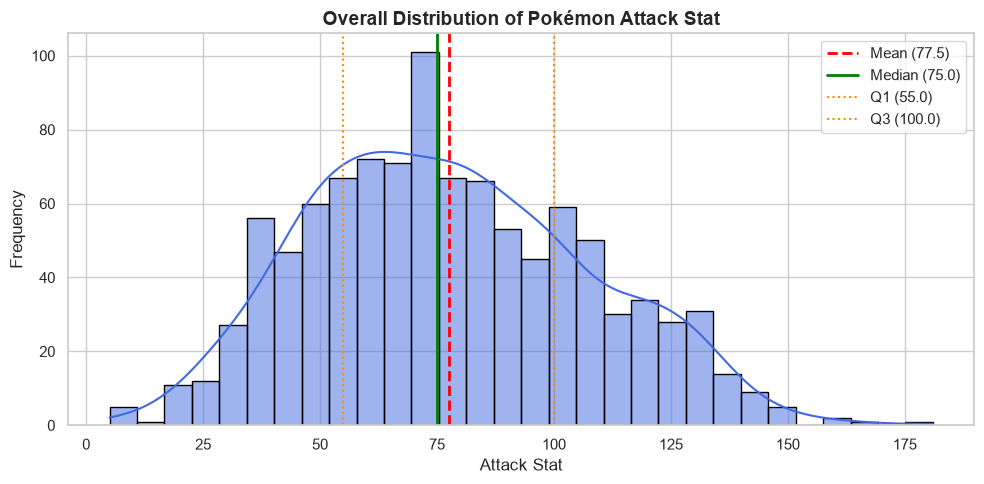

/var/folders/g2/79rch54d72d4blfd7ts13kzw0000gn/T/ipykernel_40354/992524106.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=filtered_df, x="primary_type", y="attack", palette="Set2")
/var/folders/g2/79rch54d72d4blfd7ts13kzw0000gn/T/ipykernel_40354/992524106.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=summary_df, x="Type", y="Std Dev", palette="Blues_d")


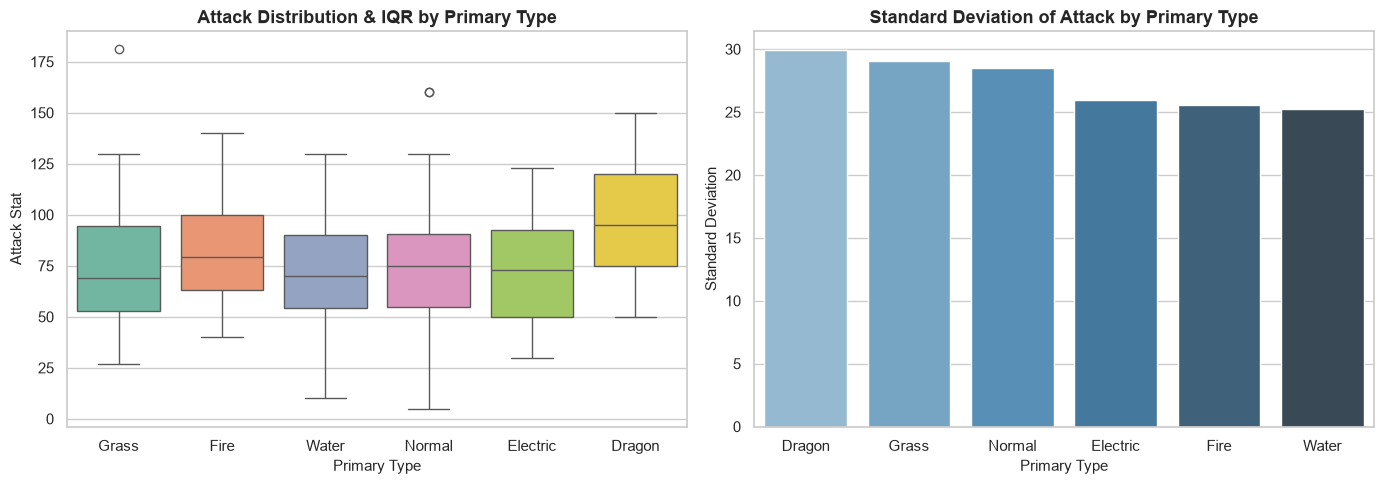

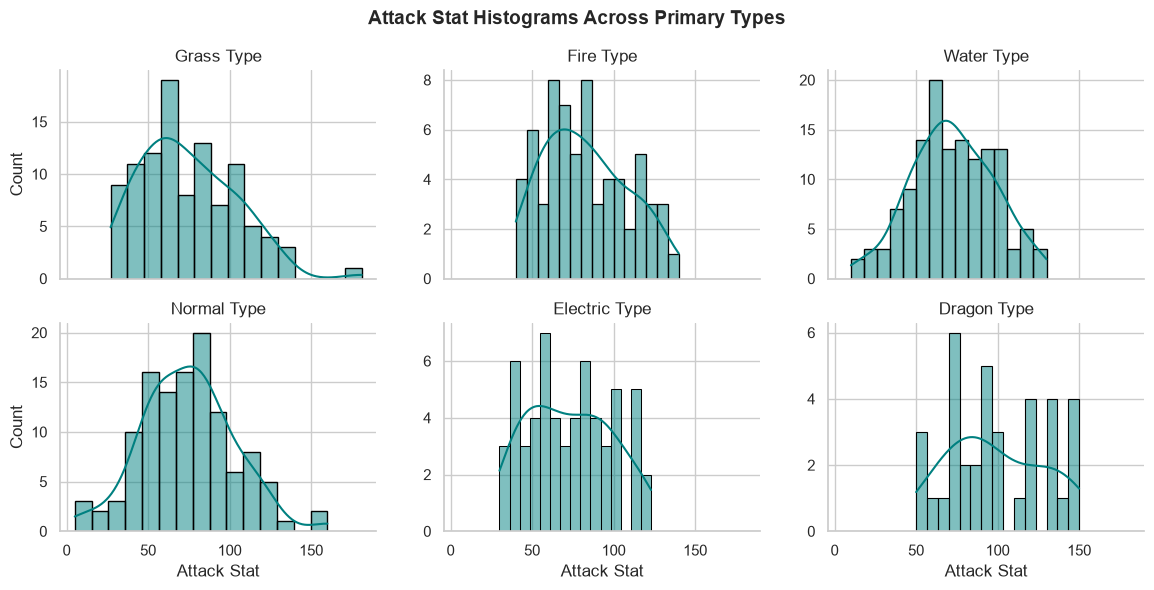

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# 1. Load the dataset
df = pd.read_csv("pokemon.csv")

# Selected types for comparison
types_to_compare = ["fire", "water", "grass", "dragon", "electric", "normal"]
filtered_df = df[df["primary_type"].isin(types_to_compare)].copy()
filtered_df["primary_type"] = filtered_df["primary_type"].str.capitalize()

# 2. Calculate Measures of Dispersion (Range, IQR, Standard Deviation)
stats_list = []
for ptype, group in filtered_df.groupby("primary_type")["attack"]:
    q25 = group.quantile(0.25)
    q75 = group.quantile(0.75)
    stats_list.append({
        "Type": ptype,
        "Count": len(group),
        "Mean": round(group.mean(), 2),
        "Range": round(group.max() - group.min(), 2),
        "IQR": round(q75 - q25, 2),
        "Std Dev": round(group.std(), 2)
    })

summary_df = pd.DataFrame(stats_list).sort_values("Std Dev", ascending=False).reset_index(drop=True)
print("=== Summary of Dispersion for Attack Stats by Type ===")
print(summary_df.to_string(index=False))

# 3. Overall Target Variable Distribution (Histogram with KDE and Markers)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="attack", kde=True, bins=30, color="royalblue", edgecolor="black")

mean_atk = df["attack"].mean()
median_atk = df["attack"].median()
q1_atk = df["attack"].quantile(0.25)
q3_atk = df["attack"].quantile(0.75)

plt.axvline(mean_atk, color="red", linestyle="--", linewidth=2, label=f"Mean ({mean_atk:.1f})")
plt.axvline(median_atk, color="green", linestyle="-", linewidth=2, label=f"Median ({median_atk:.1f})")
plt.axvline(q1_atk, color="darkorange", linestyle=":", linewidth=1.5, label=f"Q1 ({q1_atk:.1f})")
plt.axvline(q3_atk, color="darkorange", linestyle=":", linewidth=1.5, label=f"Q3 ({q3_atk:.1f})")

plt.title("Overall Distribution of Pokémon Attack Stat", fontsize=14, fontweight="bold")
plt.xlabel("Attack Stat", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Comparative Visualizations: Dispersion across Types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Boxplot for IQR, Medians, and Spread
sns.boxplot(ax=axes[0], data=filtered_df, x="primary_type", y="attack", palette="Set2")
axes[0].set_title("Attack Distribution & IQR by Primary Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Primary Type", fontsize=11)
axes[0].set_ylabel("Attack Stat", fontsize=11)

# (b) Standard Deviation Comparison
sns.barplot(ax=axes[1], data=summary_df, x="Type", y="Std Dev", palette="Blues_d")
axes[1].set_title("Standard Deviation of Attack by Primary Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Primary Type", fontsize=11)
axes[1].set_ylabel("Standard Deviation", fontsize=11)

plt.tight_layout()
plt.show()

# 5. Faceted Histograms by Type
g = sns.FacetGrid(filtered_df, col="primary_type", col_wrap=3, height=3, aspect=1.3, sharey=False)
g.map_dataframe(sns.histplot, x="attack", kde=True, bins=15, color="teal", edgecolor="black")
g.set_titles(col_template="{col_name} Type", size=12)
g.set_axis_labels("Attack Stat", "Count")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Attack Stat Histograms Across Primary Types", fontsize=14, fontweight="bold")
plt.show()

